# Short-Term Stock Price Prediction Using Support Vector Regression

## 🔹 Problem Statement

Stock market prices fluctuate daily due to multiple factors and are non-linear in nature.
The objective of this project is to predict the next day’s closing stock price using historical stock data and Support Vector Regression (SVR).

## 🔹 Why Use Support Vector Regression (SVR)?

    Stock prices show non-linear patterns

    SVR works well on small to medium datasets

    Handles noise better than linear regression

    RBF kernel can capture complex trends

--------------------------------------------------------

--------------------------------------

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_squared_error

In [6]:
data = pd.read_csv('StockPriceDataset.csv')
data.sample(5)

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
7973,2015-09-10,185.449997,187.820007,184.770004,185.910004,156.696228,3042600,GS
6915,2021-06-25,152.589996,154.500000,151.669998,154.050003,141.614960,15484900,JPM
2505,2023-12-14,198.020004,199.619995,196.160004,198.110001,197.589523,66831600,AAPL
24639,2021-12-03,197.669998,199.389999,195.740005,197.800003,187.822250,3250900,CAT
7472,2023-09-13,147.339996,147.699997,145.820007,146.410004,143.609192,8325900,JPM


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25160 entries, 0 to 25159
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       25160 non-null  object 
 1   Open       25160 non-null  float64
 2   High       25160 non-null  float64
 3   Low        25160 non-null  float64
 4   Close      25160 non-null  float64
 5   Adj Close  25160 non-null  float64
 6   Volume     25160 non-null  int64  
 7   Ticker     25160 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.5+ MB


In [8]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,25160.000000,25160.000000,25160.000000,25160.000000,25160.000000,2.516000e+04
mean,117.995756,119.114468,116.863763,118.017162,106.926655,3.163621e+07
std,74.124655,74.917398,73.325701,74.140709,72.459349,5.109620e+07
min,14.220000,14.521000,14.200000,14.347500,14.347500,4.601000e+05
25%,61.150002,61.695625,60.570000,61.169998,53.351126,6.136925e+06
50%,101.045002,101.870003,100.120003,100.985001,88.214249,1.210275e+07
75%,152.713123,154.145000,151.169998,152.679993,143.624195,3.080232e+07
max,423.119995,426.160004,413.760010,423.850006,395.366028,1.065523e+09


In [9]:
data.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

In [10]:
data['Date'] = pd.to_datetime(data['Date'])

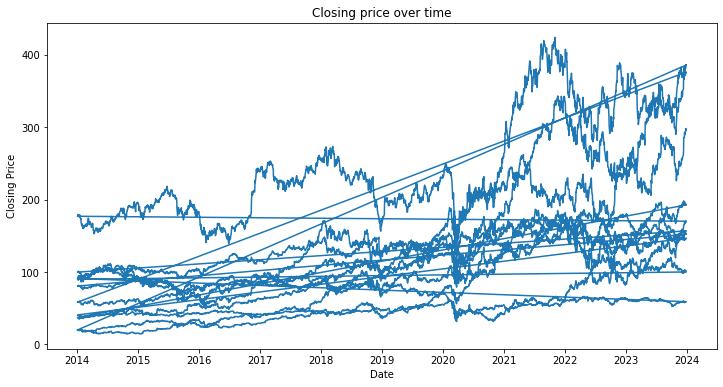

In [11]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'],data['Close'])
plt.title("Closing price over time")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

In [14]:
numeric_data = data.select_dtypes(include=[np.number])

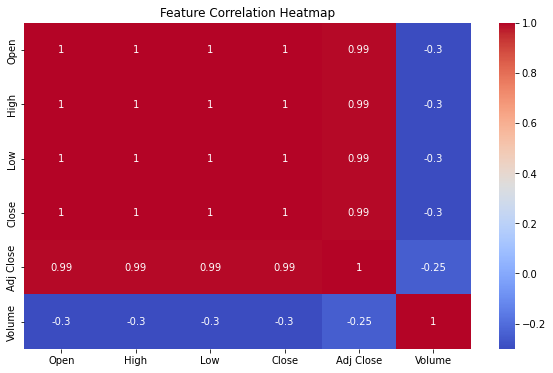

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

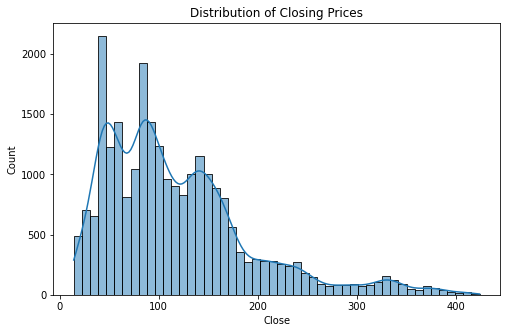

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data['Close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.show()

In [18]:
x = data[['Open','High','Low','Volume']]

y = data['Close']

In [19]:
x.head()

,Open,High,Low,Volume
0,19.845715,19.893929,19.715000,234684800
1,19.745001,19.775000,19.301071,392467600
2,19.194643,19.528570,19.057142,412610800
3,19.440001,19.498571,19.211430,317209200
4,19.243214,19.484285,19.238930,258529600


In [20]:
y.head()

0    19.754642
1    19.320715
2    19.426071
3    19.287144
4    19.409286
Name: Close, dtype: float64

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=11)

In [23]:
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20128, 4)
X_test shape: (5032, 4)
y_train shape: (20128,)
y_test shape: (5032,)


In [26]:
scaler_x = StandardScaler()

In [31]:
x_train_scale = scaler_x.fit_transform(x_train)
x_test_scale = scaler_x.transform(x_test)

In [28]:
scaler_y = StandardScaler()

In [34]:
y_train_scale = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scale = scaler_y.transform(y_test.values.reshape(-1,1))

In [35]:
print("X_train_scaled shape:", x_train_scale.shape)
print("y_train_scaled shape:", y_train_scale.shape)

X_train_scaled shape: (20128, 4)
y_train_scaled shape: (20128, 1)


In [36]:
svr_model = SVR(kernel='rbf', C=100, gamma=0.01)

svr_model.fit(x_train_scale,y_train_scale.ravel())

SVR(C=100, gamma=0.01)

In [39]:
y_pred_scaled = svr_model.predict(x_test_scale)

In [41]:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

In [42]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10].flatten()
})
print(comparison)

       Actual   Predicted
0  198.500000  194.593700
1  244.690002  248.122400
2   26.360001   27.660791
3   47.520000   49.877399
4   52.419998   53.005858
5   63.840000   66.112312
6   42.380001   47.668610
7  144.059998  142.191332
8  132.070007  130.380497
9   77.260002   78.610548


In [43]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9989283923281843


In [44]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 5.686462080861757


In [45]:
import pickle


with open('svr_model.pkl', 'wb') as f:
    pickle.dump(svr_model, f)

print("SVR model saved as 'svr_model.pkl'")

# Optionally, save the scalers too
with open('scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler_x, f)

with open('scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

print("Scalers saved as 'scaler_x.pkl' and 'scaler_y.pkl'")



SVR model saved as 'svr_model.pkl'
Scalers saved as 'scaler_x.pkl' and 'scaler_y.pkl'
